### Simple Workflow

No LLMs here, just understanding graphs and langgraph syntaxes

Eg. BMI Calculator

Input (height, weight) --> Calculate BMI --> Output

From concept of states, we know that we are going to have a state with 3 keys: weight, height, and BMI.

In [6]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict  

In [5]:
# first, we define state
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float

In [9]:
# function to calculate BMI, basically what a node should do
def calculate_bmi(state: BMIState) -> BMIState: # in this function, our state goes, and output is also a state which will be updated with new information
    weight = state['weight_kg'] # we just defined our state with weight_kg key, so we can access it like this
    height = state['height_m']
    bmi = weight / (height ** 2) # BMI formula
    state['bmi'] = round(bmi, 2) # we update our state with new key bmi
    return state # we return the updated state

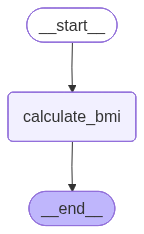

In [10]:
# define graph
graph = StateGraph(BMIState) # we define our graph with the state we just created, this will help us keep track of the state as it flows through the graph

# add nodes
graph.add_node("calculate_bmi", calculate_bmi) # the quote name is a custom name

# add edges
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", END)

# compile
workflow = graph.compile()
workflow

In [13]:
# execute graph
# initial_state = BMIState(weight_kg=70, height_m=1.75) # this works too, but we can also just use a dictionary since our state is a TypedDict
initial_state = {"weight_kg": 70, "height_m": 1.75}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 70, 'height_m': 1.75, 'bmi': 22.86}


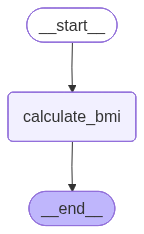

In [16]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

Making this a bit more complicated: Based on calculated BMI, we need to cateorize as under or over weight.

In [17]:
class newBMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [18]:
def bmicategory(state:newBMIState) -> newBMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        category = "Underweight"
    elif 18.5 <= bmi < 25:
        category = "Normal weight"
    elif 25 <= bmi < 30:
        category = "Overweight"
    else:
        category = "Obesity"
    state['category'] = category
    return state

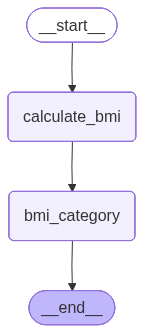

In [22]:
graph1 = StateGraph(newBMIState)
graph1.add_node("calculate_bmi", calculate_bmi)
graph1.add_node("bmi_category", bmicategory)
graph1.add_edge(START, "calculate_bmi")
graph1.add_edge("calculate_bmi", "bmi_category")
graph1.add_edge("bmi_category", END)
workflow1 = graph1.compile()
workflow1

In [21]:
initial_state1 = {"weight_kg": 120, "height_m": 1.75}
final_state1 = workflow1.invoke(initial_state1)
print(final_state1)

{'weight_kg': 120, 'height_m': 1.75, 'bmi': 39.18, 'category': 'Obesity'}
